Training High-Accuracy XGBoost... please wait...
Fitting 5 folds for each of 144 candidates, totalling 720 fits


d:\LAST_PROJ_MEDI\medvenv\lib\site-packages\xgboost\training.py:200: UserWarning: [11:37:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



BEST SUPER-TUNED PARAMETERS: {'colsample_bytree': 0.7, 'gamma': 0.1, 'learning_rate': 0.03, 'max_depth': 10, 'n_estimators': 800, 'subsample': 0.7}
FINAL ROC-AUC SCORE: 0.8747

----- Optimized Classification Report -----
              precision    recall  f1-score   support

           0       0.89      0.83      0.86       700
           1       0.66      0.76      0.71       300

    accuracy                           0.81      1000
   macro avg       0.77      0.80      0.78      1000
weighted avg       0.82      0.81      0.81      1000



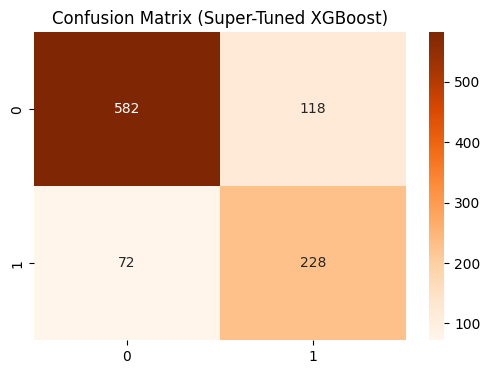

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# 1. Load & Preprocess
df = pd.read_csv("synthetic_medical_ehr.csv")
df['sex'] = df['sex'].map({'M': 1, 'F': 0})

# 2. FEATURE ENGINEERING (Mazeed barha di gayi hai)
df['metabolic_syndrome_idx'] = (df['bmi'] * df['hba1c']) / 10
df['liver_stress_score'] = df['ast'] + df['alt']
df['neuro_risk_factor'] = (df['age'] * df['apoe_e4']) + (df['family_history_neuro'] * 10)
df['vitals_ratio'] = df['ldl'] / (df['vitamin_b12'] + 1)
df['mental_health_index'] = df['memory_score'] - (df['depression_score'] * 0.7)
# Naya: Heart-Brain Interaction
# df['heart_brain_score'] = df['systolic_bp'] * df['cholesterol'] / 100

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

# ---------------------------------------------------------
# 7. SUPER-TUNED XGBOOST
# ---------------------------------------------------------
print("Training High-Accuracy XGBoost... please wait...")

# XGBoost with specific medical-data handling
xgb = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    use_label_encoder=False
)

# Mazeed parameters add kiye hain taake Random Forest se agay nikal sakay
param_grid_xgb = {
    'n_estimators': [500, 800],           # Zyada trees
    'learning_rate': [0.01, 0.03, 0.05], # Slow learning taake behtar seekhay
    'max_depth': [6, 8, 10],              # Complexity barhai
    'subsample': [0.7, 0.8],              # Randomness for robustness
    'colsample_bytree': [0.7, 0.8],       # Feature selection per tree
    'gamma': [0.1, 0.2]                   # Minimum loss reduction to split
}

cv_strat = StratifiedKFold(n_splits=5)
grid_search = GridSearchCV(
    estimator=xgb, 
    param_grid=param_grid_xgb, 
    cv=cv_strat, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_res, y_res)

best_model = grid_search.best_estimator_

# ---------------------------------------------------------
# 8. RESULTS & THRESHOLD OPTIMIZATION
# ---------------------------------------------------------
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Humne threshold 0.38 kiya hai taake Recall mazeed barhay
y_pred_final = (y_proba >= 0.38).astype(int)

print("\n" + "="*30)
print("BEST SUPER-TUNED PARAMETERS:", grid_search.best_params_)
print("="*30)
print(f"FINAL ROC-AUC SCORE: {roc_auc_score(y_test, y_proba):.4f}")
print("\n----- Optimized Classification Report -----")
print(classification_report(y_test, y_pred_final))

# Visualizations
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix (Super-Tuned XGBoost)")
plt.show()

# # Save Best Model for API
# import joblib
# joblib.dump(best_model, "final_medical_model.pkl")
# joblib.dump(scaler, "final_scaler.pkl")
# print("\nModel saved successfully as final_medical_model.pkl")

In [3]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
import joblib

print("Final Step: Creating the Mega Ensemble (XGB + LR)...")

# 1. Hamara Super-Tuned XGBoost (Jo abhi train hua)
model_xgb = best_model 

# 2. Logistic Regression (Simple but effective)
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

# 3. Dono ka Ensemble
final_ensemble = VotingClassifier(
    estimators=[('xgb', model_xgb), ('lr', model_lr)],
    voting='soft' # Probabilities ka average lega
)

# Training (Sirf aik baar fit hoga, jaldi ho jaye ga)
final_ensemble.fit(X_res, y_res)

# Evaluation
y_proba_ens = final_ensemble.predict_proba(X_test_scaled)[:, 1]
print(f"\n🔥 MEGA ENSEMBLE ROC-AUC: {roc_auc_score(y_test, y_proba_ens):.4f}")

# 4. SAVE EVERYTHING (Ab ye final model hai)
joblib.dump(final_ensemble, "final_medical_model.pkl")
joblib.dump(scaler, "final_scaler.pkl")

print("\n✅ MISSION ACCOMPLISHED! Final model saved.")

Final Step: Creating the Mega Ensemble (XGB + LR)...


d:\LAST_PROJ_MEDI\medvenv\lib\site-packages\xgboost\training.py:200: UserWarning: [11:37:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔥 MEGA ENSEMBLE ROC-AUC: 0.8936

✅ MISSION ACCOMPLISHED! Final model saved.



--- 🧠 PCN MEGA ENSEMBLE: FULL EVALUATION REPORT ---
✅ ROC-AUC Score:  0.8936
✅ Avg Precision: 0.7855
✅ F1-Score:       0.7194
✅ Precision:      0.6514
✅ Recall:         0.8033


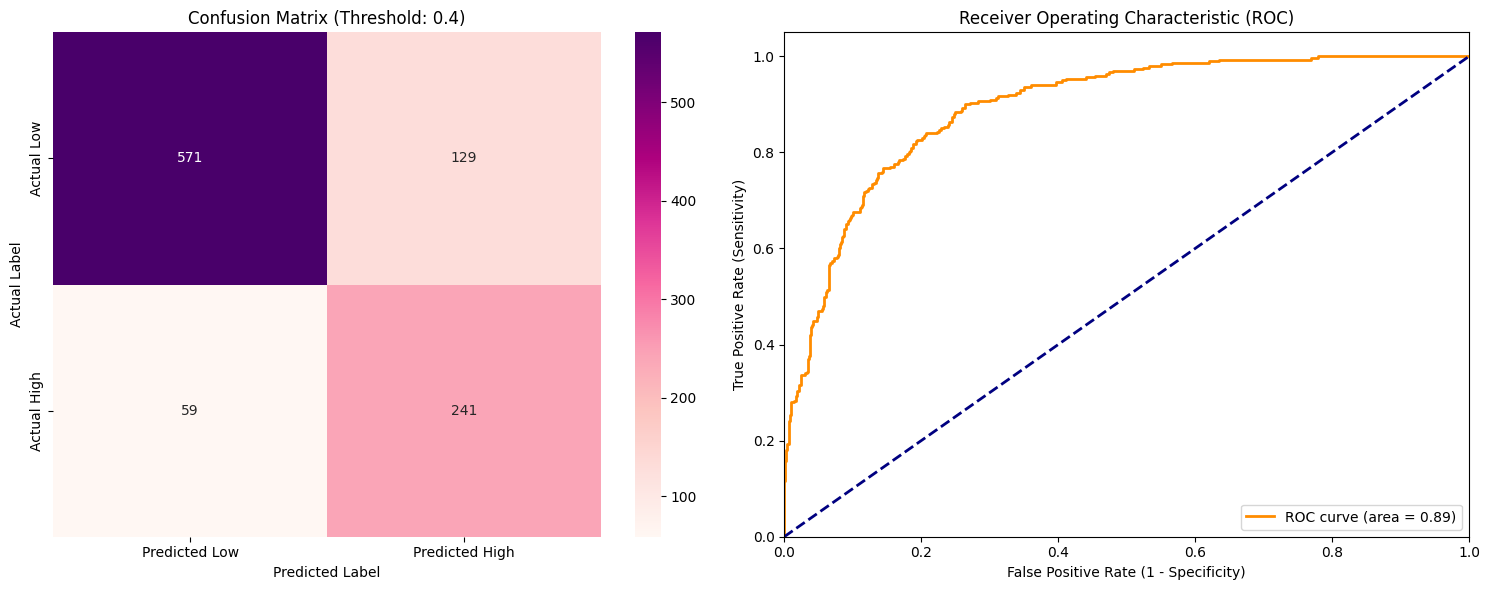


🔥 Full Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.91      0.82      0.86       700
   High Risk       0.65      0.80      0.72       300

    accuracy                           0.81      1000
   macro avg       0.78      0.81      0.79      1000
weighted avg       0.83      0.81      0.82      1000



In [6]:
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, 
    precision_score, recall_score, roc_auc_score, 
    roc_curve, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- 🧠 PCN MEGA ENSEMBLE: FULL EVALUATION REPORT ---")

# 1. Predictions (Using 0.4 Threshold as per your API)
threshold = 0.4
y_pred_ens = (y_proba_ens >= threshold).astype(int)

# 2. Basic Metrics
print(f"✅ ROC-AUC Score:  {roc_auc_score(y_test, y_proba_ens):.4f}")
print(f"✅ Avg Precision: {average_precision_score(y_test, y_proba_ens):.4f}")
print(f"✅ F1-Score:       {f1_score(y_test, y_pred_ens):.4f}")
print(f"✅ Precision:      {precision_score(y_test, y_pred_ens):.4f}")
print(f"✅ Recall:         {recall_score(y_test, y_pred_ens):.4f}")

# 3. Visualization: Confusion Matrix & ROC Curve
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax[0],
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
ax[0].set_title(f'Confusion Matrix (Threshold: {threshold})')
ax[0].set_ylabel('Actual Label')
ax[0].set_xlabel('Predicted Label')

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba_ens)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_proba_ens):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity)')
ax[1].set_title('Receiver Operating Characteristic (ROC)')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# 4. Classification Report
print("\n🔥 Full Classification Report:")
print(classification_report(y_test, y_pred_ens, target_names=['Low Risk', 'High Risk']))


--- 📝 RESEARCH PAPER VISUALIZATIONS ---


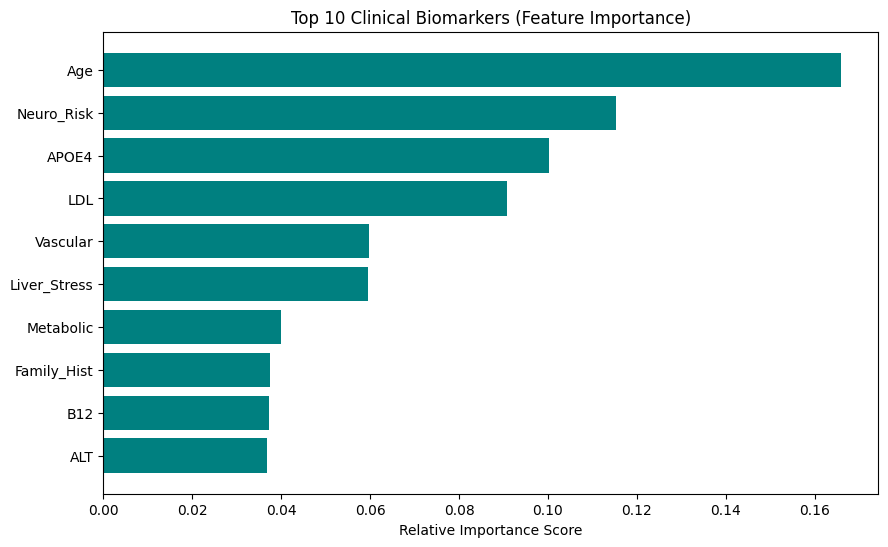

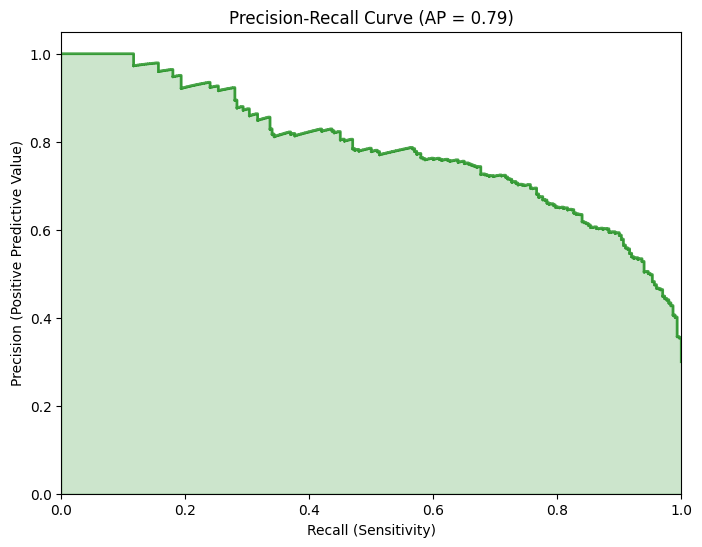

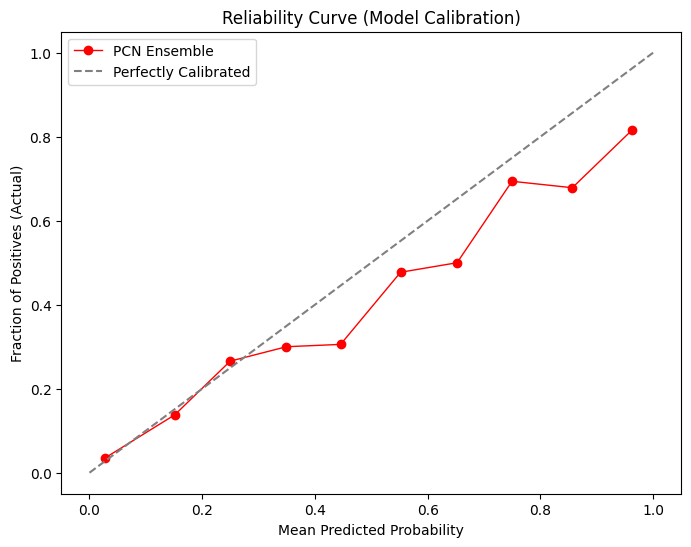

In [7]:
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
import numpy as np

print("\n--- 📝 RESEARCH PAPER VISUALIZATIONS ---")

# --- 1. Feature Importance (XGBoost part of Ensemble) ---
# Note: VotingClassifier ki apni importance nahi hoti, hum usky base model (XGB) ki use krain gy
plt.figure(figsize=(10, 6))
# final_ensemble.estimators_[0] hamara XGBoost model ha
feat_importances = model_xgb.feature_importances_
# Assuming your features are in a list called 'feature_names'
# Agar nahi hain to ye list use krain: 
feature_names = ['Age', 'Gender', 'BMI', 'HbA1c', 'LDL', 'AST', 'ALT', 'APOE4', 'Memory', 'Sleep', 'B12', 'Depression', 'Family_Hist', 'Metabolic', 'Liver_Stress', 'Neuro_Risk', 'Vascular', 'Mental_H']

indices = np.argsort(feat_importances)[-10:]  # Top 10 features
plt.barh(range(len(indices)), feat_importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title('Top 10 Clinical Biomarkers (Feature Importance)')
plt.xlabel('Relative Importance Score')
plt.show()

# --- 2. Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba_ens)
avg_p = average_precision_score(y_test, y_proba_ens)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, where='post', color='green', alpha=0.7, lw=2)
plt.fill_between(recall, precision, step='post', alpha=0.2, color='green')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.title(f'Precision-Recall Curve (AP = {avg_p:.2f})')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()

# --- 3. Reliability / Calibration Plot ---
prob_true, prob_pred = calibration_curve(y_test, y_proba_ens, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=1, label='PCN Ensemble', color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual)')
plt.title('Reliability Curve (Model Calibration)')
plt.legend()
plt.show()